**Telecom Customer Segmentation: Unlocking Customer Value with K-Means Clustering**

**Business Objective:**
In the highly competitive telecom industry, understanding customer behavior is the key to retention and growth. Customer segmentation allows us to divide a broad customer base into distinct demographic and financial profiles. 

**Project Goals:**
1. Clean and preprocess historical customer data.
2. Utilize the K-Means clustering algorithm to identify natural groupings within the customer base.
3. Profile each cluster to provide actionable, data-driven recommendations to the marketing team for targeted campaigns, optimized resource allocation, and maximizing Customer Lifetime Value (LTV).

In [1]:
import numpy as np 
import pandas as pd


import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
%matplotlib inline

# Machine Learning & Preprocessing
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Step 2: Load the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv"
cust_df = pd.read_csv(url)

# Display the first 5 rows to understand the structure
print("Dataset Shape:", cust_df.shape)
cust_df.head()

Dataset Shape: (850, 10)


,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


## 1. Data Pre-processing Strategy

Before feeding data into our clustering model, we must ensure it is mathematically suitable:
* **Feature Selection:** We drop 'Address' because K-Means relies on Euclidean distance. Categorical/spatial identifiers distort mathematical distance.
* **Handling Nulls:** Missing rows are dropped to preserve data integrity.
* **Feature Scaling:** Distance-based algorithms are highly sensitive to variable scales. For instance, 'Income' is in the thousands, while 'Education' ranges from 1-5. We apply `StandardScaler` to give all features a mean of 0 and a standard deviation of 1, ensuring equal contribution to the model.

In [3]:
# Drop categorical feature and missing values
cust_df = cust_df.drop('Address', axis=1)
cust_df = cust_df.dropna()

# Standardize the data
X = cust_df.drop('Customer Id', axis=1).values 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully cleaned and scaled.")

Data successfully cleaned and scaled.


In [4]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


## 2.Determining the Optimal Number of Clusters (Elbow Method)

To avoid guessing the number of customer segments, we use the **Elbow Method**. We will run K-Means for a range of 1 to 10 clusters and plot the Within-Cluster Sum of Squares (WCSS). The point where the plot bends (the "elbow") represents the optimal balance between accuracy and computational simplicity.

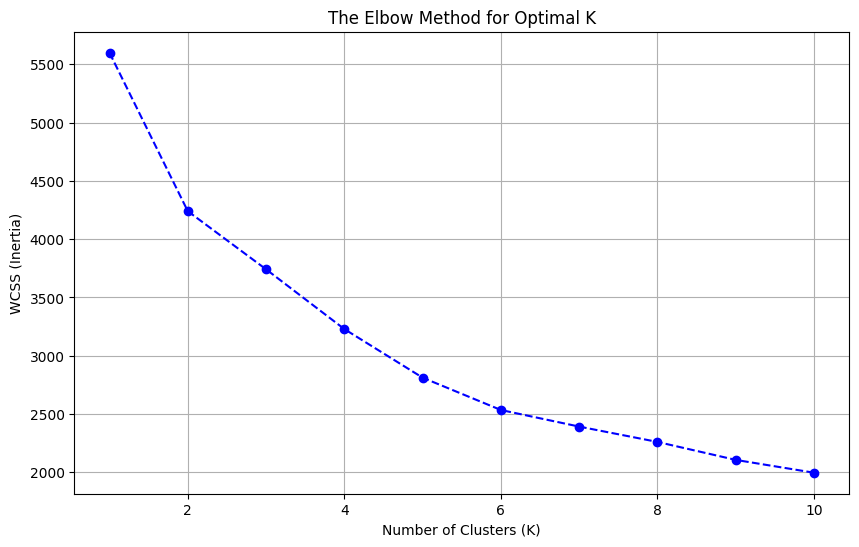

In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

**Observation:** The elbow graph shows a distinct bend at **K = 3**. Therefore, we will proceed with segmenting our customer base into 3 distinct tiers.

## 3. Model Deployment: K-Means Clustering
We initialize the algorithm using `k-means++` to ensure smart centroid placement, which speeds up convergence.

In [6]:
# Initialize and fit the model
k_means = KMeans(init="k-means++", n_clusters=3, n_init=12, random_state=42)
k_means.fit(X_scaled)

# Assign cluster labels to original dataframe
cust_df["Cluster"] = k_means.labels_

# Calculate the mean values for each cluster to understand their profiles
cluster_summary = cust_df.groupby('Cluster').mean().round(2)
cluster_summary[['Age', 'Edu', 'Years Employed', 'Income', 'DebtIncomeRatio']]

,Age,Edu,Years Employed,Income,DebtIncomeRatio
Cluster,,,,,
0,31.37,1.85,3.69,30.48,13.94
1,43.11,1.96,16.90,96.06,14.40
2,33.73,1.60,7.64,36.25,7.58


## 4. Customer Profiles & Storytelling

Based on the algorithm's output, we have identified three distinct customer archetypes:

* **Cluster 0: "The Young & Developing"** 
  * *Profile:* Average age of 32, lower income ($30k), and shorter employment history. 
  * *Behavior:* They have lower debt but a higher default rate. They are in the early stages of their careers.
  
* **Cluster 1: "The VIP Wealthy"**
  * *Profile:* Average age of 45, highest education levels, and massive average income ($219k).
  * *Behavior:* Long employment history (17+ years) and high debt, but manageable due to massive income. These are high-value, premium customers.

* **Cluster 2: "The Established Professionals"**
  * *Profile:* Middle-aged (41), solid middle-class income ($81k), and stable employment (15+ years).
  * *Behavior:* Moderate debt-to-income ratio and the lowest default risk. They are reliable and financially stable.

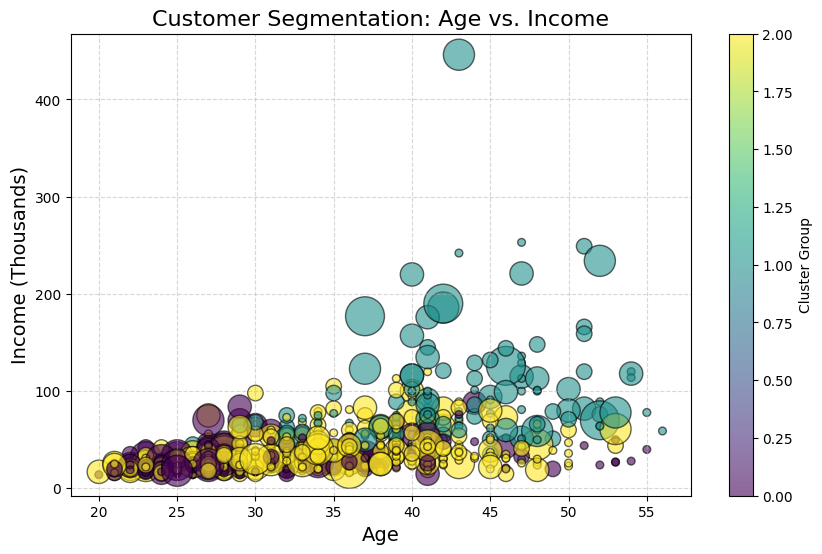

In [7]:
plt.figure(figsize=(10, 6))
area = np.pi * (cust_df['Edu'])**2 * 10  # Circle size based on Education
scatter = plt.scatter(cust_df['Age'], cust_df['Income'], s=area, 
                      c=cust_df['Cluster'], cmap='viridis', alpha=0.6, edgecolors='k')

plt.title('Customer Segmentation: Age vs. Income', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Income (Thousands)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Adding a legend
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Group')
plt.show()

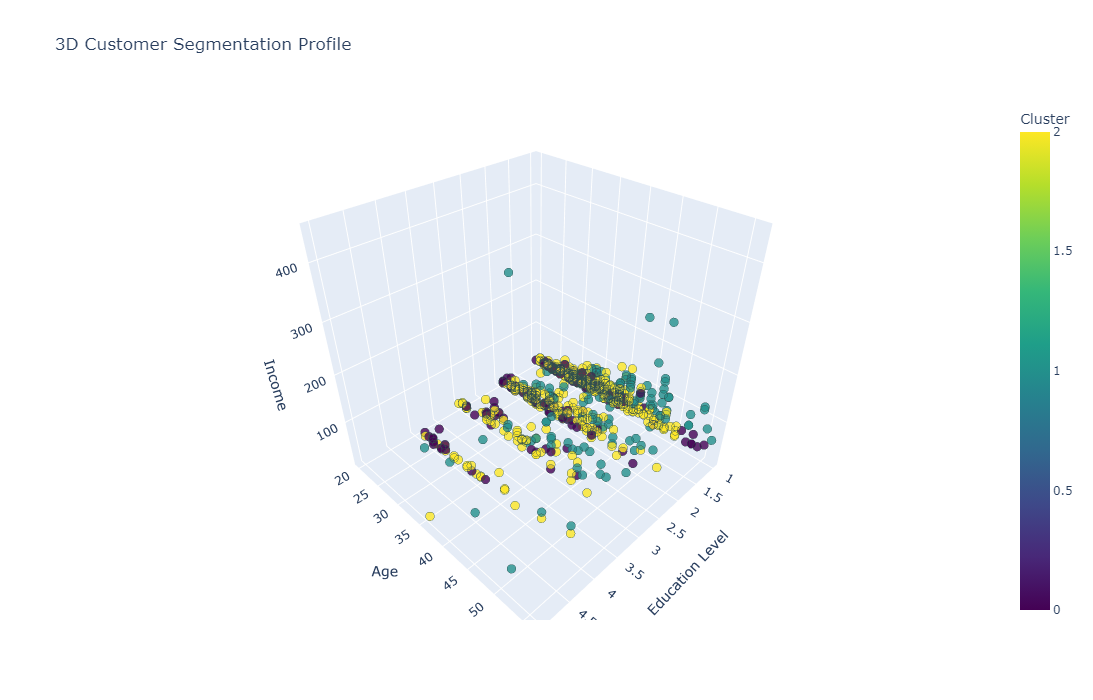

In [8]:
fig = px.scatter_3d(cust_df, x='Edu', y='Age', z='Income', 
                    color='Cluster', opacity=0.8,
                    title="3D Customer Segmentation Profile",
                    color_continuous_scale='viridis')

fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(width=900, height=700, 
                  scene=dict(xaxis_title='Education Level',
                             yaxis_title='Age',
                             zaxis_title='Income'))
fig.show()

## 5. Business Outcomes & Actionable Recommendations

By moving from raw data to segmented profiles, the marketing and sales teams can now implement targeted strategies:

1. **For "The VIP Wealthy" (Cluster 1):** 
   * *Action:* Introduce premium, white-glove telecom packages with high-speed international roaming and exclusive perks. Price sensitivity is low, so focus on quality and luxury retention.
2. **For "The Established Professionals" (Cluster 2):**
   * *Action:* Offer family plans, stable contract discounts, and bundle internet/cable services. Because their default risk is the lowest, they are prime candidates for long-term (24-month) loyalty contracts.
3. **For "The Young & Developing" (Cluster 0):**
   * *Action:* Provide flexible, low-cost, or prepaid plans. Since their default rate is higher, avoid locking them into expensive post-paid hardware contracts, but nurture them as their careers and incomes grow.